In [1]:
import pandas as pd
import numpy as np
import scipy.stats as st

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
import matplotlib.pyplot as plt


In [2]:
predicted_genotypes = pd.read_csv('../../1_figure_CL_proof_of_concept/data/3cl_predicted_genotypes.csv',sep=',')
predicted_genotypes = predicted_genotypes.pivot(index='name', columns='cell_type', values='genotype_from_bulk').copy()
predicted_genotypes = predicted_genotypes.replace({'homozygous_ref': 'wt', 'homozygous_alt': 'mutated'})
predicted_genotypes.dropna(inplace=True)
predicted_genotypes.drop('HTT c.8157G>A', inplace=True)

variants = ~((predicted_genotypes.isin(['mutated','heterozygous']).sum(axis=1) == 3) | (predicted_genotypes.isin(['wt','heterozygous']).sum(axis=1) == 3))
variants = variants[variants].index ### subset to only variants where a single probe wouldn't be all correct or all incorrect


In [3]:
single_probe = pd.read_csv('../output/single_probe_3plex_counts.csv', index_col=1)[['genotype','allele_call','count','correct']]

dual_probe = pd.read_csv('../output/dual_probe_3plex_counts.csv', index_col=1)[['genotype','allele_call','count','correct','variant']]
dual_probe_LHS = dual_probe.loc[dual_probe['variant'] == 'lhs'].drop('variant',axis=1).copy()
dual_probe_RHS = dual_probe.loc[dual_probe['variant'] == 'rhs'].drop('variant',axis=1).copy()


In [4]:
merged = single_probe.merge(dual_probe, on=['name','genotype','allele_call','correct'], suffixes=('_single','_dual')).sort_values('name')
merged = merged.loc[merged.index.isin(variants), :]

In [5]:
accuracy_single_probe = merged.loc[merged['correct']].groupby('name')['count_single'].sum()/merged.groupby('name')['count_single'].sum()
accuracy_dual_probe_LHS = merged.loc[merged['correct']].groupby('name')['count_dual'].sum()/merged.groupby('name')['count_dual'].sum()

merged_accuracies = pd.DataFrame([accuracy_single_probe, accuracy_dual_probe_LHS], index=['single', 'dual']).T

merged_accuracies = merged_accuracies.reindex(variants).dropna()


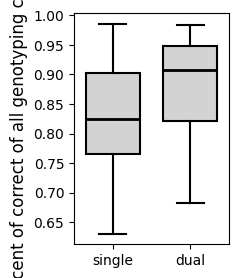

In [6]:
fig, ax = plt.subplots(figsize=(2,3))

data = [
    (merged_accuracies['single']).dropna(),
    (merged_accuracies['dual']).dropna()
]
ax.boxplot(
    data,
    tick_labels=[
        'single',
        'dual'
    ],
    patch_artist=True,
    boxprops=dict(facecolor='lightgrey', color='k', linewidth=1.5),
    medianprops=dict(color='k', linewidth=2),
    whiskerprops=dict(color='k', linewidth=1.5),
    capprops=dict(color='k', linewidth=1.5),
    showfliers=False,
    widths=0.7  # Make boxes wider
)

ax.set_ylabel('Percent of correct of all genotyping counts', fontsize=12)
plt.savefig('../plots/dual_vs_single_probe_accuracy_3plex.pdf', bbox_inches='tight')

In [7]:
c1 = 'single'
c2 = 'dual'

l1 = merged_accuracies.dropna(subset=[c1,c2])[c1]
l2 = merged_accuracies.dropna(subset=[c1,c2])[c2]

print(len(l1), len(l2))
st.wilcoxon(l1, l2, alternative='less')

12 12


WilcoxonResult(statistic=7.0, pvalue=0.004638671875)